# Energy Consumption Forecasting
Comparing SARIMA/Prophet vs XGBoost (lag features) vs LSTM on hourly energy data.

## 0. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from prophet import Prophet
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Config
SEED = 42
TEST_WEEKS = 4          # hold out last 4 weeks as test set
SEQ_LEN = 168           # LSTM lookback window: 1 week of hourly data
BATCH_SIZE = 64
EPOCHS = 30
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

np.random.seed(SEED)
torch.manual_seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


## 1. Load & Inspect Dataset
Download from: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption
Use `AEP_hourly.csv` (largest region, ~121k rows).

In [2]:
df = pd.read_csv('AEP_hourly.csv', parse_dates=['Datetime'], index_col='Datetime')
df = df.sort_index()
df.columns = ['energy']
print(df.shape)
df.head()

(121273, 1)


,energy
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


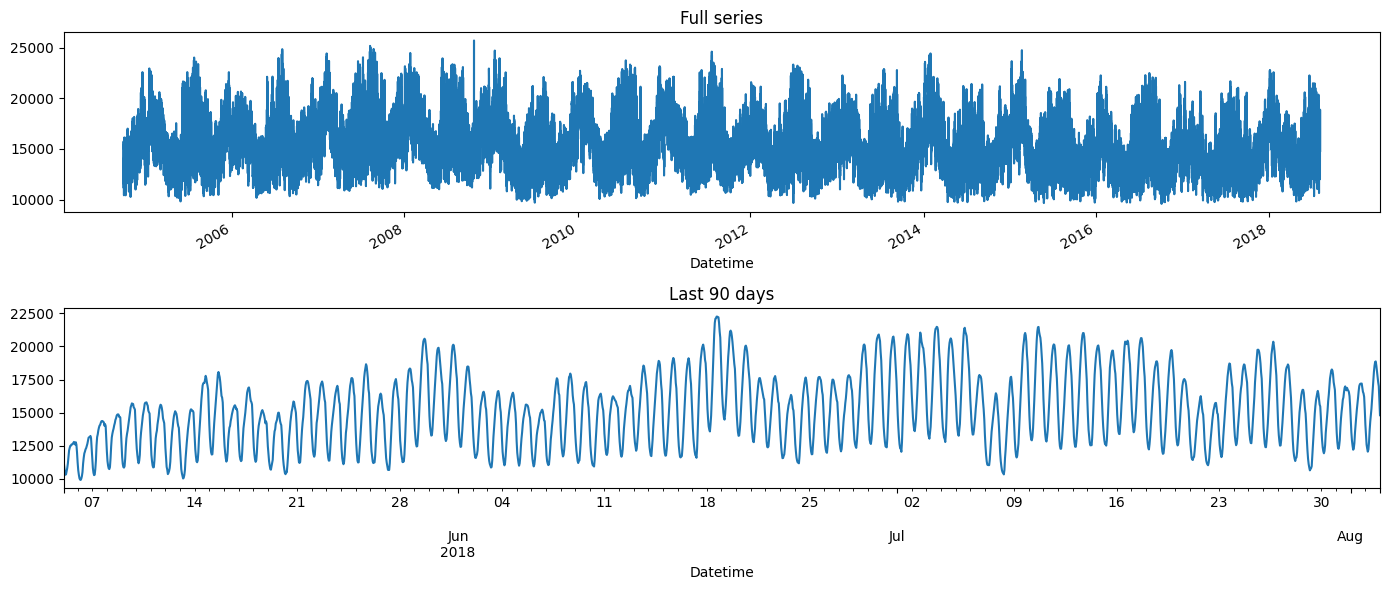

In [3]:
# Quick look at the series
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
df['energy'].plot(ax=axes[0], title='Full series')
df['energy'].iloc[-24*90:].plot(ax=axes[1], title='Last 90 days')
plt.tight_layout()
plt.savefig('series_overview.png', dpi=150)
plt.show()

## 2. Train / Test Split
Hold out last 4 weeks. No shuffling â€” temporal order must be preserved.

In [4]:
test_size = TEST_WEEKS * 7 * 24
train = df.iloc[:-test_size].copy()
test  = df.iloc[-test_size:].copy()
print(f'Train: {len(train)} | Test: {len(test)}')

Train: 120601 | Test: 672


## 3. Baseline - Prophet

In [5]:
# Prophet expects columns: ds, y
prophet_train = train.reset_index().rename(columns={'Datetime': 'ds', 'energy': 'y'})

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode='multiplicative'
)
m.fit(prophet_train)

# 'h' is the pandas 2.x standard; older Prophet versions may need 'H'
future = m.make_future_dataframe(periods=test_size, freq='h')
forecast = m.predict(future)

prophet_pred = forecast['yhat'].iloc[-test_size:].values
prophet_mae  = mean_absolute_error(test['energy'], prophet_pred)
prophet_mape = np.mean(np.abs((test['energy'].values - prophet_pred) / test['energy'].values)) * 100
print(f'Prophet - MAE: {prophet_mae:.2f} | MAPE: {prophet_mape:.2f}%')

16:30:04 - cmdstanpy - INFO - Chain [1] start processing
16:31:28 - cmdstanpy - INFO - Chain [1] done processing


Prophet - MAE: 1535.93 | MAPE: 10.33%


## 4. Feature Engineering - XGBoost

In [6]:
def make_features(df):
    df = df.copy()
    # Calendar features
    df['hour']       = df.index.hour
    df['dayofweek']  = df.index.dayofweek
    df['month']      = df.index.month
    df['quarter']    = df.index.quarter
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
    # Lag features
    for lag in [1, 24, 48, 168]:
        df[f'lag_{lag}'] = df['energy'].shift(lag)
    # Rolling statistics (computed on past only â€” no leakage)
    df['rolling_mean_24']  = df['energy'].shift(1).rolling(24).mean()
    df['rolling_std_24']   = df['energy'].shift(1).rolling(24).std()
    df['rolling_mean_168'] = df['energy'].shift(1).rolling(168).mean()
    return df

# Build features on full df so lags are available at train/test boundary
df_feat = make_features(df).dropna()

FEATURE_COLS = [c for c in df_feat.columns if c != 'energy']
X = df_feat[FEATURE_COLS]
y = df_feat['energy']

X_train_xgb = X.iloc[:-test_size]
y_train_xgb = y.iloc[:-test_size]
X_test_xgb  = X.iloc[-test_size:]
y_test_xgb  = y.iloc[-test_size:]

## 5. XGBoost

In [7]:
# Validation split from train (last 2 weeks) â€” early stopping must not see the test set
val_size_xgb = 2 * 7 * 24
X_tr  = X_train_xgb.iloc[:-val_size_xgb]
y_tr  = y_train_xgb.iloc[:-val_size_xgb]
X_val = X_train_xgb.iloc[-val_size_xgb:]
y_val = y_train_xgb.iloc[-val_size_xgb:]

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=SEED,
    verbosity=0
)
xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred = xgb.predict(X_test_xgb)
xgb_mae  = mean_absolute_error(y_test_xgb, xgb_pred)
xgb_mape = np.mean(np.abs((y_test_xgb.values - xgb_pred) / y_test_xgb.values)) * 100
print(f'XGBoost - MAE: {xgb_mae:.2f} | MAPE: {xgb_mape:.2f}%')

XGBoost - MAE: 133.58 | MAPE: 0.85%


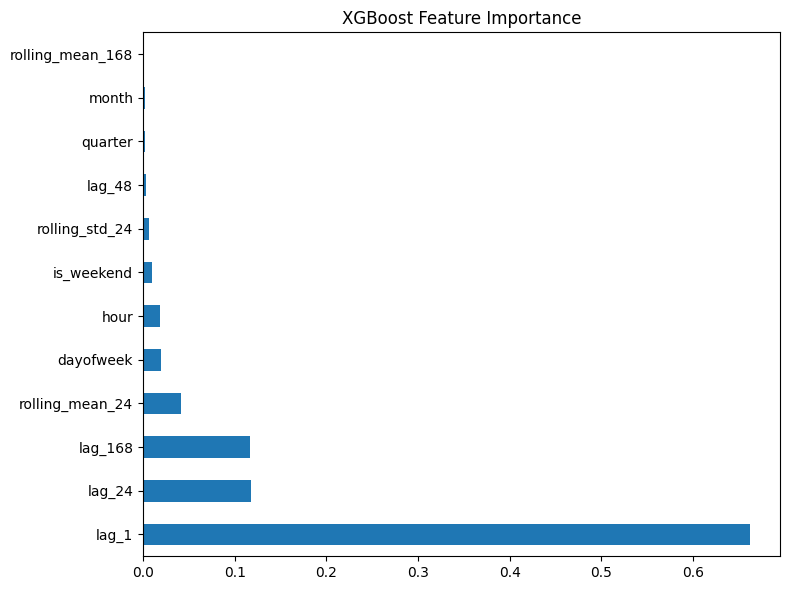

In [8]:
# Feature importance
feat_imp = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
feat_imp.head(15).plot(kind='barh', figsize=(8, 6), title='XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 6. LSTM - Dataset

In [9]:
def build_lstm_features(df):
    feats = pd.DataFrame(index=df.index)
    feats['energy']     = df['energy']
    # Encoding ciclico per preservare la circolaritÃ  (ora 23 â‰ˆ ora 0)
    feats['sin_hour']   = np.sin(2 * np.pi * df.index.hour / 24)
    feats['cos_hour']   = np.cos(2 * np.pi * df.index.hour / 24)
    feats['sin_dow']    = np.sin(2 * np.pi * df.index.dayofweek / 7)
    feats['cos_dow']    = np.cos(2 * np.pi * df.index.dayofweek / 7)
    feats['sin_month']  = np.sin(2 * np.pi * (df.index.month - 1) / 12)
    feats['cos_month']  = np.cos(2 * np.pi * (df.index.month - 1) / 12)
    feats['is_weekend'] = (df.index.dayofweek >= 5).astype(float)
    return feats

train_feats = build_lstm_features(train)
test_feats  = build_lstm_features(test)

# Scala solo l'energia; le feature cicliche sono giÃ  in [-1, 1]
energy_scaler = StandardScaler()
train_feats['energy'] = energy_scaler.fit_transform(train_feats[['energy']])
test_feats['energy']  = energy_scaler.transform(test_feats[['energy']])

N_FEATURES = train_feats.shape[1]  # 8

train_arr = train_feats.values.astype(np.float32)
test_arr  = test_feats.values.astype(np.float32)

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data    = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]    # (seq_len, N_FEATURES)
        y = self.data[idx + self.seq_len, 0]        # energia scalata (colonna 0)
        return x, y.unsqueeze(0)                    # â†’ (1,) per MSELoss

# Prepend last SEQ_LEN rows of train so first test window is valid
test_full_arr = np.concatenate([train_arr[-SEQ_LEN:], test_arr])

train_dataset = TimeSeriesDataset(train_arr,     SEQ_LEN)
test_dataset  = TimeSeriesDataset(test_full_arr, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)
print(f'Input features: {N_FEATURES}')

Input features: 8


## 7. LSTM  Model & Training

In [10]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=N_FEATURES, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)         # (batch, seq_len, hidden)
        return self.fc(out[:, -1, :]) # last timestep â†’ (batch, 1)

model     = LSTMForecaster().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}')

Epoch 5/30 | Loss: 0.005030
Epoch 10/30 | Loss: 0.003949
Epoch 15/30 | Loss: 0.003441
Epoch 20/30 | Loss: 0.003157
Epoch 25/30 | Loss: 0.002969
Epoch 30/30 | Loss: 0.002837


## 8. LSTM  Evaluation

In [11]:
model.eval()
preds = []
with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(DEVICE)
        preds.append(model(x_batch).cpu().numpy())

lstm_pred_scaled = np.concatenate(preds).reshape(-1, 1)
lstm_pred = energy_scaler.inverse_transform(lstm_pred_scaled).flatten()
y_test_lstm = test['energy'].values

assert len(lstm_pred) == len(y_test_lstm), \
    f'Length mismatch: lstm_pred={len(lstm_pred)}, test={len(y_test_lstm)}'

lstm_mae  = mean_absolute_error(y_test_lstm, lstm_pred)
lstm_mape = np.mean(np.abs((y_test_lstm - lstm_pred) / y_test_lstm)) * 100
print(f'LSTM  MAE: {lstm_mae:.2f} | MAPE: {lstm_mape:.2f}%')

LSTM  MAE: 94.35 | MAPE: 0.61%


## 9. PatchTST

In [12]:
EPOCHS_TST = 50

class PatchTST(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, patch_len=16, stride=8,
                 n_features=N_FEATURES, d_model=128, nhead=8,
                 num_layers=3, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.patch_len   = patch_len
        self.stride      = stride
        self.num_patches = (seq_len - patch_len) // stride + 1  # 20 patches

        self.patch_proj = nn.Linear(patch_len * n_features, d_model)
        self.pos_emb    = nn.Parameter(torch.zeros(1, self.num_patches, d_model))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout     = nn.Dropout(dropout)
        self.head        = nn.Linear(self.num_patches * d_model, 1)

    def forward(self, x):
        B = x.shape[0]
        patches = x.unfold(1, self.patch_len, self.stride).permute(0, 1, 3, 2)
        patches = patches.reshape(B, self.num_patches, -1)
        tokens  = self.dropout(self.patch_proj(patches) + self.pos_emb)
        out     = self.transformer(tokens)
        return self.head(out.reshape(B, -1))

patchtst  = PatchTST().to(DEVICE)
optimizer = torch.optim.Adam(patchtst.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5)
criterion = nn.MSELoss()

print(f'Patches: {patchtst.num_patches}  |  Params: {sum(p.numel() for p in patchtst.parameters()):,}')

train_losses_tst = []
for epoch in range(EPOCHS_TST):
    patchtst.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = patchtst(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(patchtst.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses_tst.append(avg_loss)
    scheduler.step(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS_TST} | Loss: {avg_loss:.6f}')


Patches: 20  |  Params: 419,073
Epoch 10/50 | Loss: 0.007796
Epoch 20/50 | Loss: 0.007329
Epoch 30/50 | Loss: 0.004888
Epoch 40/50 | Loss: 0.004770
Epoch 50/50 | Loss: 0.004741


In [13]:
patchtst.eval()
preds_tst = []
with torch.no_grad():
    for x_batch, _ in test_loader:
        preds_tst.append(patchtst(x_batch.to(DEVICE)).cpu().numpy())

patchtst_pred_scaled = np.concatenate(preds_tst).reshape(-1, 1)
patchtst_pred = energy_scaler.inverse_transform(patchtst_pred_scaled).flatten()
y_test_patchtst = test['energy'].values

assert len(patchtst_pred) == len(y_test_patchtst), \
    f'Length mismatch: {len(patchtst_pred)} vs {len(y_test_patchtst)}'

patchtst_mae  = mean_absolute_error(y_test_patchtst, patchtst_pred)
patchtst_mape = np.mean(np.abs((y_test_patchtst - patchtst_pred) / y_test_patchtst)) * 100
print(f'PatchTST — MAE: {patchtst_mae:.2f} | MAPE: {patchtst_mape:.2f}%')


PatchTST — MAE: 141.22 | MAPE: 0.94%


## 10. Model Comparison

   Model         MAE      MAPE
 Prophet 1535.933164 10.329325
 XGBoost  133.584656  0.849000
    LSTM   94.345834  0.609510
PatchTST  141.223187  0.939508


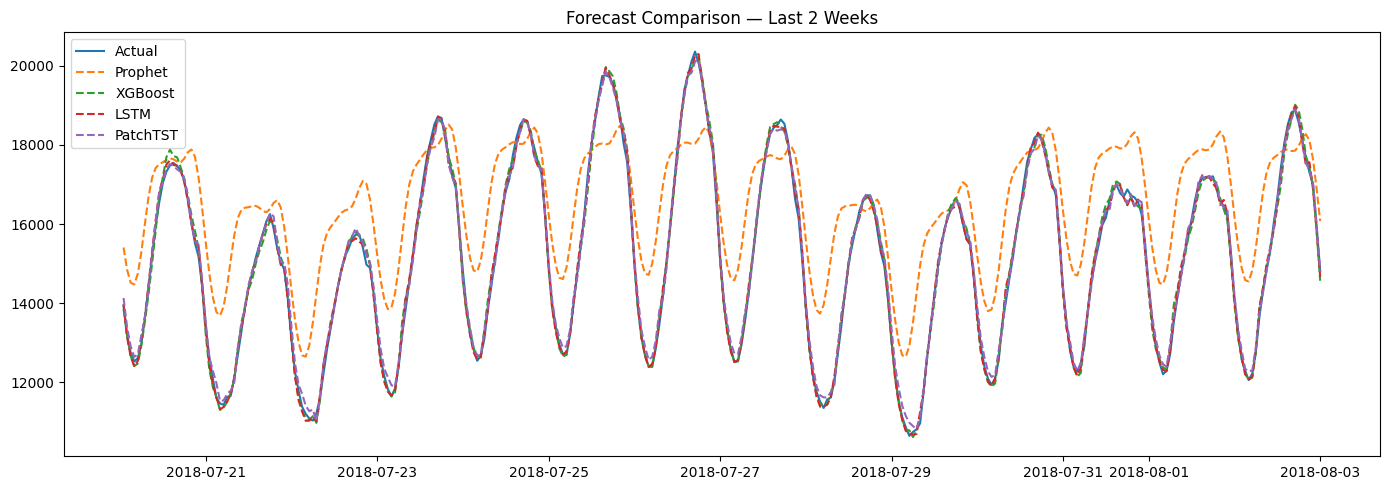

In [14]:
results = pd.DataFrame({
    'Model': ['Prophet', 'XGBoost', 'LSTM', 'PatchTST'],
    'MAE':   [prophet_mae, xgb_mae, lstm_mae, patchtst_mae],
    'MAPE':  [prophet_mape, xgb_mape, lstm_mape, patchtst_mape]
})
print(results.to_string(index=False))

plot_n = 24 * 14
plt.figure(figsize=(14, 5))
plt.plot(test.index[-plot_n:], test['energy'].values[-plot_n:],  label='Actual',   linewidth=1.5)
plt.plot(test.index[-plot_n:], prophet_pred[-plot_n:],           label='Prophet',   linestyle='--')
plt.plot(test.index[-plot_n:], xgb_pred[-plot_n:],              label='XGBoost',   linestyle='--')
plt.plot(test.index[-plot_n:], lstm_pred[-plot_n:],             label='LSTM',      linestyle='--')
plt.plot(test.index[-plot_n:], patchtst_pred[-plot_n:],         label='PatchTST',  linestyle='--')
plt.legend()
plt.title('Forecast Comparison — Last 2 Weeks')
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150)
plt.show()


## 11. Save Models

In [15]:
import joblib
torch.save(model.state_dict(),    'lstm_forecaster.pt')
torch.save(patchtst.state_dict(), 'patchtst_forecaster.pt')
joblib.dump(xgb,           'xgb_forecaster.pkl')
joblib.dump(energy_scaler, 'energy_scaler.pkl')
print('Models saved.')


Models saved.
